# Bank Marketing

Dataset-specific starting notebook for the DataFrameSampler paper experiments.

Claim-specific role: mixed-type business classification benchmark for subscription prediction, campaign-context preservation, and configuration-effort checks.


## Setup

Run the downloader before executing this notebook:

```bash
python experiments/download_datasets.py
```

Dataset-specific choices live in `experiments/datasets.py`; the reusable execution path lives in `experiments/workflow.py`.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distributions, plot_pairwise_features
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view_from_config, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.workflow import dataset_profile, experiment_paths, load_dataset, notebook_environment, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import preprocessing_plan, vectorization_plan

DATASET_NAME = "bank_marketing"
CONFIG = DATASET_CONFIGS[DATASET_NAME]
PATHS = experiment_paths(CONFIG, root=ROOT)
notebook_environment(PATHS)


{'python': '3.11.13',
 'pandas': '2.3.3',
 'dataset': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/bank_marketing.csv'}

## Load Prepared Data

Exploration uses the prepared source dataframe before the experiment workflow fits or samples anything.


In [2]:
dataframe = load_dataset(CONFIG, root=ROOT)
work = working_dataframe(dataframe, CONFIG)
profile = dataset_profile(dataframe)
dataframe.shape, dataframe.head()


((41188, 21),
    age        job  marital    education default housing loan    contact month  \
 0   56  housemaid  married     basic.4y      no      no   no  telephone   may   
 1   57   services  married  high.school     NaN      no   no  telephone   may   
 2   37   services  married  high.school      no     yes   no  telephone   may   
 3   40     admin.  married     basic.6y      no      no   no  telephone   may   
 4   56   services  married  high.school      no      no  yes  telephone   may   
 
   day_of_week  ...  campaign  pdays  previous     poutcome emp_var_rate  \
 0         mon  ...         1    999         0  nonexistent          1.1   
 1         mon  ...         1    999         0  nonexistent          1.1   
 2         mon  ...         1    999         0  nonexistent          1.1   
 3         mon  ...         1    999         0  nonexistent          1.1   
 4         mon  ...         1    999         0  nonexistent          1.1   
 
    cons_price_idx  cons_conf_idx 

## Target Column Choice

The predictive task uses this target column from the prepared dataframe.

In [3]:
target_column_choice(CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,subscribed,classification,True,2,0,Configured in experiments/datasets.py and used...


## Dataset Profile

The reusable Bank Marketing configuration uses a fixed 3,000-row working sample so exact experiment comparisons run quickly while preserving a reproducible path to the full campaign table.


In [4]:
profile


,dtype,missing,unique
age,int64,0,78
job,object,330,11
marital,object,80,3
education,object,1731,7
default,object,8597,2
housing,object,990,2
loan,object,990,2
contact,object,0,2
month,object,0,10
day_of_week,object,0,5


## Column Vectorization Plan

These are the columns that require vectorization before latent learning. The table records whether each column is numeric, directly mapped, discarded as high-cardinality, binary categorical, or NCA latent encoded to one numeric coordinate.


In [5]:
pre_plan = preprocessing_plan(CONFIG)
if not pre_plan.empty:
    display(pre_plan)

vector_plan = vectorization_plan(dataframe, CONFIG)
vector_plan[vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,strategy,latent_components,high_cardinality_warning,rationale
1,job,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
2,marital,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
3,education,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
4,default,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
5,housing,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
6,loan,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
7,contact,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
8,month,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
9,day_of_week,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
14,poutcome,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

These cells run before `run_configured_dataset_experiment`. They summarize every column, plot per-column distributions on the human-readable dataframe, and show pairwise feature relationships after the configured sampler has reduced the working sample to numeric coordinates.


In [6]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,age,int64,0.000000,78,numeric,40.02406,10.42125,17,38.0,98,
1,job,object,0.008012,11,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,admin.: 0.26; blue-collar: 0.23; technician: 0...
2,marital,object,0.001942,3,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,married: 0.61; single: 0.28; divorced: 0.11
3,education,object,0.042027,7,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,university.degree: 0.31; high.school: 0.24; ba...
4,default,object,0.208726,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,no: 1.00; yes: 0.00
5,housing,object,0.024036,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,yes: 0.54; no: 0.46
6,loan,object,0.024036,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,no: 0.84; yes: 0.16
7,contact,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,cellular: 0.63; telephone: 0.37
8,month,object,0.000000,10,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,may: 0.33; jul: 0.17; aug: 0.15; jun: 0.13; no...
9,day_of_week,object,0.000000,5,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,thu: 0.21; mon: 0.21; wed: 0.20; tue: 0.20; fr...


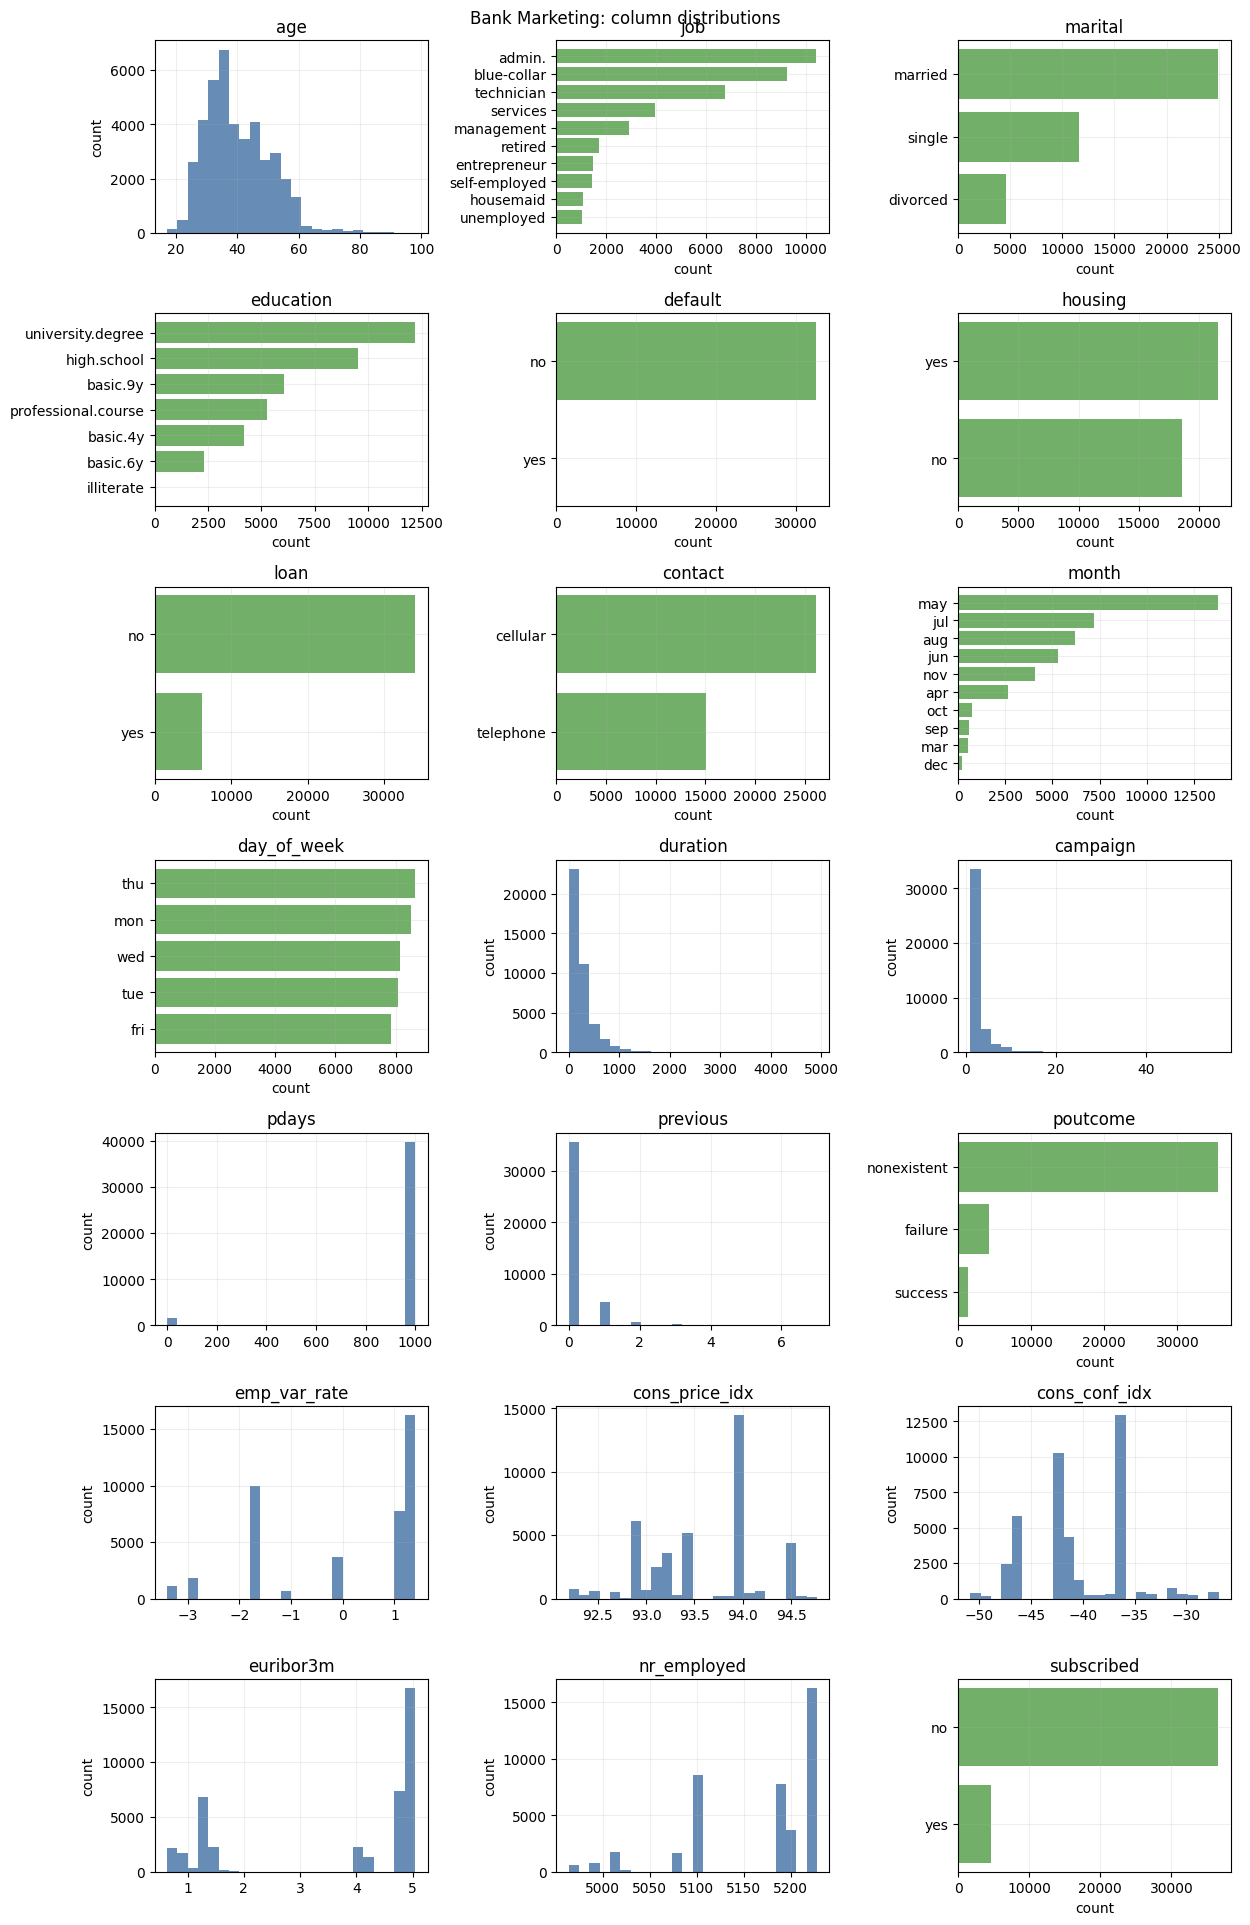

In [7]:
_ = plot_column_distributions(dataframe, title="Bank Marketing")

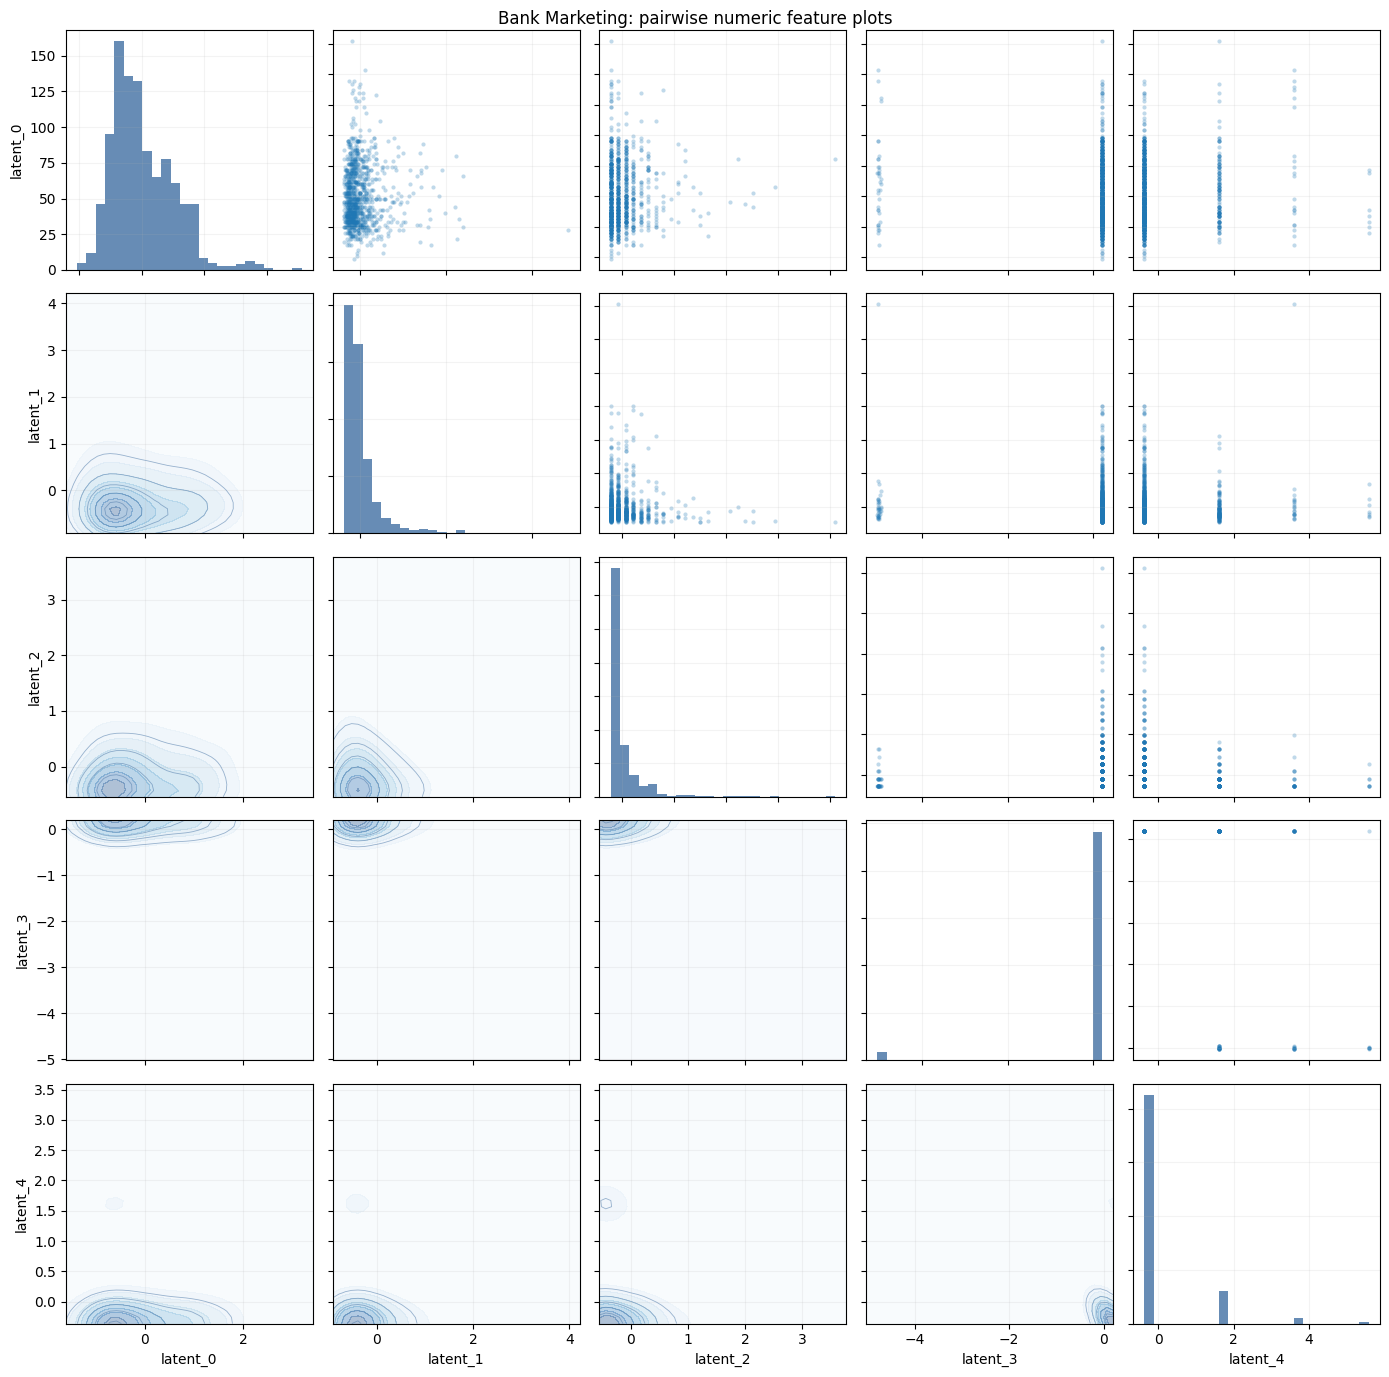

In [8]:
numeric_work = numeric_view_from_config(work, CONFIG)
_ = plot_pairwise_features(numeric_work, target_column=CONFIG.target_column, title="Bank Marketing")

## Run Experiment

The full sampler/baseline workflow runs after the exploratory cells.


In [ ]:
result = run_configured_dataset_experiment(CONFIG, root=ROOT)
result.paths


## Starter DataFrameSampler Run

The workflow writes the generated starter sample, quick similarity report, and runtime row to `experiments/results/`.


In [ ]:
result.starter_run.fit_seconds, result.starter_run.sample_seconds, result.starter_run.generated.head()


In [ ]:
result.starter_run.similarity_report


## Numeric Projection Of Generated Data

In [ ]:
_ = plot_numeric_projection_triptych(
    result.starter_run.sampler,
    result.working_dataframe,
    result.starter_run.generated,
    target_column=CONFIG.target_column,
    title=CONFIG.title,
    reducer="umap",
    random_state=CONFIG.random_state,
)


## Baseline and Configuration Comparison

The same workflow runs DataFrameSampler default/manual configurations and the simple baselines, then writes the comparison CSV.


In [ ]:
result.comparison


In [ ]:
summarize_manifold_validation(result.manifold_validation)


In [ ]:
summarize_mechanism_validation(result.mechanism_validation)


In [ ]:
summarize_decoder_calibration(result.decoder_calibration)


## Predictive Target Evaluation

The real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [ ]:
predictive_report = predictive_performance_report(work, CONFIG)
predictive_report
